In [6]:
import xarray as xr
import numpy as np

In [1]:
PATHS = {
    "0.25deg": "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr",
    "1.5deg":  "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr",
    "5.625deg":"gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr",
    }

In [3]:
CHANNELS = [
    {"short_name": "u10",   "name": "10m_u_component_of_wind",   "level": None},
    {"short_name": "v10",   "name": "10m_v_component_of_wind",   "level": None},
    {"short_name": "t2m",   "name": "2m_temperature",            "level": None},
    {"short_name": "sp",    "name": "surface_pressure",          "level": None},
    {"short_name": "mslp",  "name": "mean_sea_level_pressure",   "level": None},
    {"short_name": "t850",  "name": "temperature",               "level": 850},
    {"short_name": "u1000", "name": "u_component_of_wind",       "level": 1000},
    {"short_name": "v1000", "name": "v_component_of_wind",       "level": 1000},
    {"short_name": "z1000", "name": "geopotential",              "level": 1000},
    {"short_name": "u850",  "name": "u_component_of_wind",       "level": 850},
    {"short_name": "v850",  "name": "v_component_of_wind",       "level": 850},
    {"short_name": "z850",  "name": "geopotential",              "level": 850},
    {"short_name": "u500",  "name": "u_component_of_wind",       "level": 500},
    {"short_name": "v500",  "name": "v_component_of_wind",       "level": 500},
    {"short_name": "z500",  "name": "geopotential",              "level": 500},
    {"short_name": "t500",  "name": "temperature",               "level": 500},
    {"short_name": "z50",   "name": "geopotential",              "level": 50},
    {"short_name": "r500",  "name": "relative_humidity",         "level": 500},
    {"short_name": "r850",  "name": "relative_humidity",         "level": 850},
    {"short_name": "tcwv",  "name": "total_column_water_vapour", "level": None},
]

## Checking for all 20 channels

In [4]:
def open_dataset(path: str) -> xr.Dataset:
    """Open a zarr store, trying anonymous GCS access first."""
    try:
        return xr.open_zarr(path, storage_options={"token": "anon"}, consolidated=True)
    except Exception:
        # fall back to default credentials / non-consolidated metadata
        return xr.open_zarr(path)


def level_coord_values(ds: xr.Dataset):
    for cand in ("level", "plev", "isobaricInhPa"):
        if cand in ds.coords:
            return cand, {float(v) for v in ds[cand].values}
    return None, set()


def check_dataset(path: str):
    ds = open_dataset(path)
    level_name, levels = level_coord_values(ds)

    results = []
    for ch in CHANNELS:
        var, lvl, short = ch["name"], ch["level"], ch["short_name"]

        if var not in ds.data_vars and var not in ds.variables:
            results.append((short, var, lvl, False, "variable not found"))
            continue

        if lvl is None:
            results.append((short, var, lvl, True, "ok"))
            continue

        da = ds[var]
        if level_name is None or level_name not in da.dims:
            results.append((short, var, lvl, False, "no level dimension on variable"))
        elif float(lvl) not in levels:
            results.append((short, var, lvl, False, f"level {lvl} not present"))
        else:
            results.append((short, var, lvl, True, "ok"))

    return results

In [5]:
def main():
    for label, path in PATHS.items():
        print(f"\n=== {label}: {path} ===")
        try:
            results = check_dataset(path)
        except Exception as e:
            print(f"  FAILED TO OPEN DATASET: {e}")
            continue

        missing = [r for r in results if not r[3]]
        for short, var, lvl, ok, msg in results:
            status = "OK  " if ok else "MISS"
            lvl_str = "" if lvl is None else f" @ {lvl}"
            print(f"  [{status}] {short:8s} ({var}{lvl_str}) - {msg}")

        print(f"  --> {len(results) - len(missing)}/{len(results)} channels present")
        if missing:
            print(f"  --> missing: {[r[0] for r in missing]}")


if __name__ == "__main__":
    main()


=== 0.25deg: gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr ===


I0808 15:23:05.390829 46920802 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0808 15:23:05.396332 46920824 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)


  [OK  ] u10      (10m_u_component_of_wind) - ok
  [OK  ] v10      (10m_v_component_of_wind) - ok
  [OK  ] t2m      (2m_temperature) - ok
  [OK  ] sp       (surface_pressure) - ok
  [OK  ] mslp     (mean_sea_level_pressure) - ok
  [OK  ] t850     (temperature @ 850) - ok
  [OK  ] u1000    (u_component_of_wind @ 1000) - ok
  [OK  ] v1000    (v_component_of_wind @ 1000) - ok
  [OK  ] z1000    (geopotential @ 1000) - ok
  [OK  ] u850     (u_component_of_wind @ 850) - ok
  [OK  ] v850     (v_component_of_wind @ 850) - ok
  [OK  ] z850     (geopotential @ 850) - ok
  [OK  ] u500     (u_component_of_wind @ 500) - ok
  [OK  ] v500     (v_component_of_wind @ 500) - ok
  [OK  ] z500     (geopotential @ 500) - ok
  [OK  ] t500     (temperature @ 500) - ok
  [OK  ] z50      (geopotential @ 50) - ok
  [MISS] r500     (relative_humidity @ 500) - variable not found
  [MISS] r850     (relative_humidity @ 850) - variable not found
  [OK  ] tcwv     (total_column_water_vapour) - ok
  --> 18/20 channels

## Checking how data is stored

In [8]:
TARGET_LAT_DESCENDING = True     # True -> 90 to -90, False -> -90 to 90
TARGET_LON_CONVENTION = "0_360"  # "0_360" or "-180_180"

LAT_NAME_CANDIDATES = ("latitude", "lat")
LON_NAME_CANDIDATES = ("longitude", "lon")



def find_coord_name(ds: xr.Dataset, candidates) -> str:
    for c in candidates:
        if c in ds.coords:
            return c
    raise KeyError(f"None of {candidates} found in dataset coords: {list(ds.coords)}")


def diagnose(ds: xr.Dataset) -> dict:
    lat_name = find_coord_name(ds, LAT_NAME_CANDIDATES)
    lon_name = find_coord_name(ds, LON_NAME_CANDIDATES)
    lat = ds[lat_name].values
    lon = ds[lon_name].values

    lat_descending = bool(lat[0] > lat[-1])
    lon_convention = "0_360" if lon.min() >= -1e-6 and lon.max() > 180 else "-180_180"

    needs_lat_flip = lat_descending != TARGET_LAT_DESCENDING
    needs_lon_convert = lon_convention != TARGET_LON_CONVENTION

    return {
        "lat_name": lat_name,
        "lon_name": lon_name,
        "lat_range": (float(lat.min()), float(lat.max())),
        "lat_descending": lat_descending,
        "lat_len": len(lat),
        "lon_range": (float(lon.min()), float(lon.max())),
        "lon_convention": lon_convention,
        "lon_len": len(lon),
        "needs_lat_flip": needs_lat_flip,
        "needs_lon_convert": needs_lon_convert,
    }


def fix_dataset(ds: xr.Dataset, diag: dict) -> xr.Dataset:
    """Return a copy of ds re-oriented to the target convention."""
    lat_name, lon_name = diag["lat_name"], diag["lon_name"]

    if diag["needs_lat_flip"]:
        ds = ds.isel({lat_name: slice(None, None, -1)})

    if diag["needs_lon_convert"]:
        if TARGET_LON_CONVENTION == "0_360":
            new_lon = ds[lon_name] % 360
        else:  # "-180_180"
            new_lon = ((ds[lon_name] + 180) % 360) - 180
        ds = ds.assign_coords({lon_name: new_lon}).sortby(lon_name)

    return ds


def quick_plot(ds: xr.Dataset, diag: dict, var: str, title: str):
    """Plot one time/level slice of `var` with coastlines to eyeball orientation."""
    import matplotlib.pyplot as plt

    da = ds[var]
    # squeeze down to (lat, lon) by taking first index of any other dims
    extra_dims = [d for d in da.dims if d not in (diag["lat_name"], diag["lon_name"])]
    if extra_dims:
        da = da.isel({d: 0 for d in extra_dims})

    fig, ax = plt.subplots(figsize=(8, 4))
    da.plot(ax=ax, x=diag["lon_name"], y=diag["lat_name"], add_colorbar=True)
    try:
        # optional: draw real coastlines if cartopy is installed
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        plt.close(fig)
        fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()})
        da.plot(ax=ax, x=diag["lon_name"], y=diag["lat_name"],
                 transform=ccrs.PlateCarree(), add_colorbar=True)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    except ImportError:
        pass  # matplotlib-only fallback above still shows the raw grid

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [10]:
def main():
    diagnostics = {}
    fixed = {}

    for label, path in PATHS.items():
        print(f"\n=== {label}: {path} ===")
        try:
            ds = open_dataset(path)
        except Exception as e:
            print(f"  FAILED TO OPEN DATASET: {e}")
            continue

        diag = diagnose(ds)
        diagnostics[label] = diag
        print(f"  lat: '{diag['lat_name']}' range={diag['lat_range']} "
              f"({'descending 90->-90' if diag['lat_descending'] else 'ascending -90->90'}), "
              f"len={diag['lat_len']}")
        print(f"  lon: '{diag['lon_name']}' range={diag['lon_range']} "
              f"({diag['lon_convention']}), len={diag['lon_len']}")

        actions = []
        if diag["needs_lat_flip"]:
            actions.append("FLIP latitude order")
        if diag["needs_lon_convert"]:
            actions.append(f"CONVERT longitude to {TARGET_LON_CONVENTION}")
        print(f"  --> action needed: {', '.join(actions) if actions else 'none, already matches target'}")

        fixed[label] = fix_dataset(ds, diag)

    # summary table
    print("\n=== summary ===")
    for label, diag in diagnostics.items():
        print(f"  {label}: lat_flip={diag['needs_lat_flip']}, "
              f"lon_convert({diag['lon_convention']}->{TARGET_LON_CONVENTION})={diag['needs_lon_convert']}")

    return fixed, diagnostics


=== 0.25deg: gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr ===
  lat: 'latitude' range=(-90.0, 90.0) (descending 90->-90), len=721
  lon: 'longitude' range=(0.0, 359.75) (0_360), len=1440
  --> action needed: none, already matches target

=== 1.5deg: gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr ===
  lat: 'latitude' range=(-90.0, 90.0) (ascending -90->90), len=121
  lon: 'longitude' range=(0.0, 358.5) (0_360), len=240
  --> action needed: FLIP latitude order

=== 5.625deg: gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr ===
  lat: 'latitude' range=(-87.18750000000003, 87.18750000000003) (ascending -90->90), len=32
  lon: 'longitude' range=(0.0, 354.375) (0_360), len=64
  --> action needed: FLIP latitude order

=== summary ===
  0.25deg: lat_flip=False, lon_convert(0_360->0_360)=False
  1.5deg: lat_flip=True, lon_convert(0_360->0_360)=False
  5.625deg: lat_flip=True,

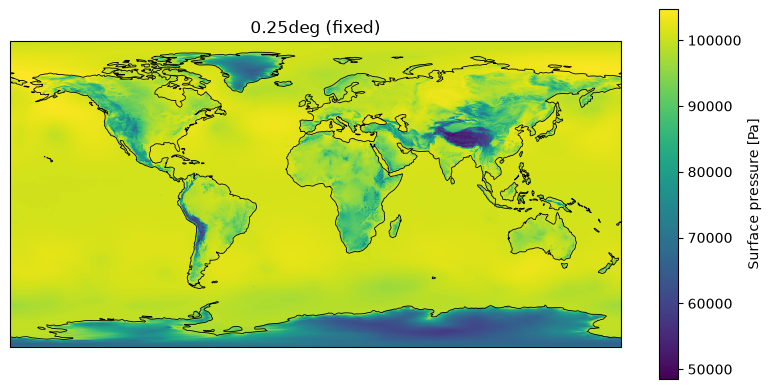

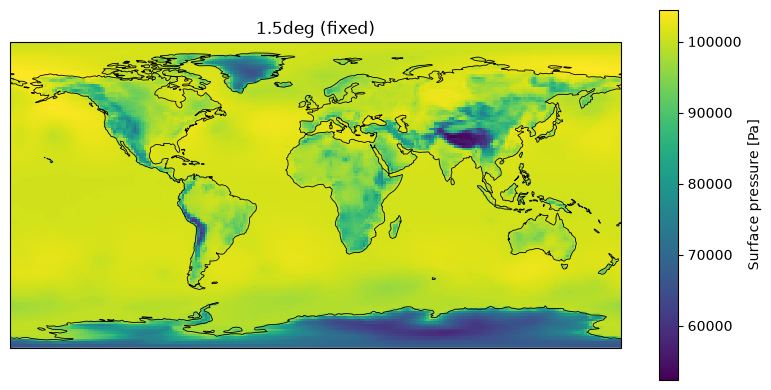

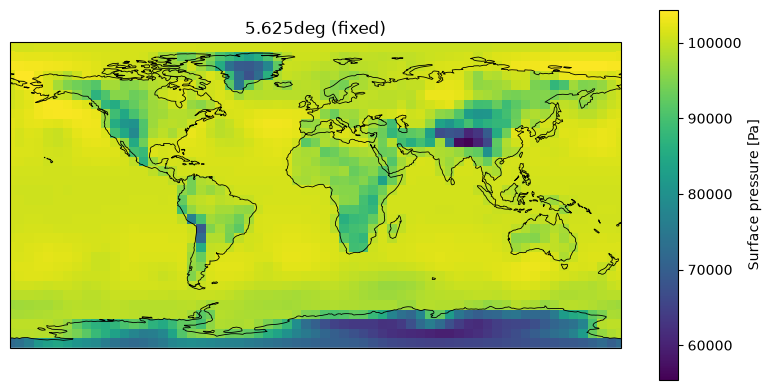

In [12]:

if __name__ == "__main__":
    fixed_datasets, diagnostics = main()

    # Uncomment to visually sanity-check orientation after fixing
    # (pick a variable you know is in all 3 datasets, e.g. 2m_temperature)
    #
    for label, ds in fixed_datasets.items():
        quick_plot(ds, diagnostics[label], "surface_pressure", title=f"{label} (fixed)")